# I. Importation of librairies and dataset

## 1. Librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

In [4]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

## 2. Dataset

In [6]:
df = pd.read_csv('Churn_Modelling.csv')

In [7]:
df.rename(columns={'is_churned': 'is_inactive'}, inplace=True)

# II. Dataset analysis

In [8]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10002 non-null  int64  
 1   CustomerId       10002 non-null  int64  
 2   Surname          10002 non-null  object 
 3   CreditScore      10002 non-null  int64  
 4   Geography        10001 non-null  object 
 5   Gender           10002 non-null  object 
 6   Age              10001 non-null  float64
 7   Tenure           10002 non-null  int64  
 8   Balance          10002 non-null  float64
 9   NumOfProducts    10002 non-null  int64  
 10  HasCrCard        10001 non-null  float64
 11  IsActiveMember   10001 non-null  float64
 12  EstimatedSalary  10002 non-null  float64
 13  Exited           10002 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 1.1+ MB
None


## 1. Number of columns/rows

In [9]:
print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Shape: (10002, 14)
Rows: 10002, Columns: 14


## 2. Number of values

In [10]:
# Basic statistics
print(df.describe())

          RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10002.000000  1.000200e+04  10002.000000  10001.000000  10002.000000   
mean    5001.499600  1.569093e+07    650.555089     38.922311      5.012498   
std     2887.472338  7.193177e+04     96.661615     10.487200      2.891973   
min        1.000000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2501.250000  1.562852e+07    584.000000     32.000000      3.000000   
50%     5001.500000  1.569073e+07    652.000000     37.000000      5.000000   
75%     7501.750000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.000000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts     HasCrCard  IsActiveMember  \
count   10002.000000   10002.000000  10001.000000    10001.000000   
mean    76491.112875       1.530194      0.705529        0.514949   
std     62393.474144       0.581639      0.455827        0.499801   
min         

In [11]:
# Categorical variables summary
categorical_cols = ['Surname', 'Geography', 'Gender']
for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


Surname:
Surname
Smith        32
Martin       29
Walker       29
Scott        29
Brown        26
             ..
Hull          1
Sturdee       1
Flannagan     1
Dwyer         1
Corby         1
Name: count, Length: 2932, dtype: int64

Geography:
Geography
France     5014
Germany    2510
Spain      2477
Name: count, dtype: int64

Gender:
Gender
Male      5458
Female    4544
Name: count, dtype: int64


## 3. Variables definition

In [12]:
print(df.dtypes)

RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                float64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard          float64
IsActiveMember     float64
EstimatedSalary    float64
Exited               int64
dtype: object


In [13]:
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender   Age  \
0          1    15634602  Hargrave          619    France  Female  42.0   
1          2    15647311      Hill          608     Spain  Female  41.0   
2          3    15619304      Onio          502    France  Female  42.0   
3          4    15701354      Boni          699    France  Female  39.0   
4          5    15737888  Mitchell          850     Spain  Female  43.0   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1        1.0             1.0   
1       1   83807.86              1        0.0             1.0   
2       8  159660.80              3        1.0             0.0   
3       1       0.00              2        0.0             0.0   
4       2  125510.82              1        NaN             1.0   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4      

## 4. Quality

In [14]:
# Data range and potential outliers
numeric_cols = ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Min: {df[col].min()}, Max: {df[col].max()}")
    print(f"  Mean: {df[col].mean():.2f}, Median: {df[col].median()}")

    # Check for potential outliers using IQR method
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"  Potential outliers: {len(outliers)}")


RowNumber:
  Min: 1, Max: 10000
  Mean: 5001.50, Median: 5001.5
  Potential outliers: 0

CustomerId:
  Min: 15565701, Max: 15815690
  Mean: 15690933.45, Median: 15690732.0
  Potential outliers: 0

CreditScore:
  Min: 350, Max: 850
  Mean: 650.56, Median: 652.0
  Potential outliers: 15

Age:
  Min: 18.0, Max: 92.0
  Mean: 38.92, Median: 37.0
  Potential outliers: 359

Tenure:
  Min: 0, Max: 10
  Mean: 5.01, Median: 5.0
  Potential outliers: 0

Balance:
  Min: 0.0, Max: 250898.09
  Mean: 76491.11, Median: 97198.54000000001
  Potential outliers: 0

NumOfProducts:
  Min: 1, Max: 4
  Mean: 1.53, Median: 1.0
  Potential outliers: 60

HasCrCard:
  Min: 0.0, Max: 1.0
  Mean: 0.71, Median: 1.0
  Potential outliers: 0

IsActiveMember:
  Min: 0.0, Max: 1.0
  Mean: 0.51, Median: 1.0
  Potential outliers: 0

EstimatedSalary:
  Min: 11.58, Max: 199992.48
  Mean: 100083.33, Median: 100185.23999999999
  Potential outliers: 0

Exited:
  Min: 0, Max: 1
  Mean: 0.20, Median: 0.0
  Potential outliers: 20

## 5. Visualization

In [15]:
plt.style.use('default')
sns.set_palette("husl")

### i. Variables distributions

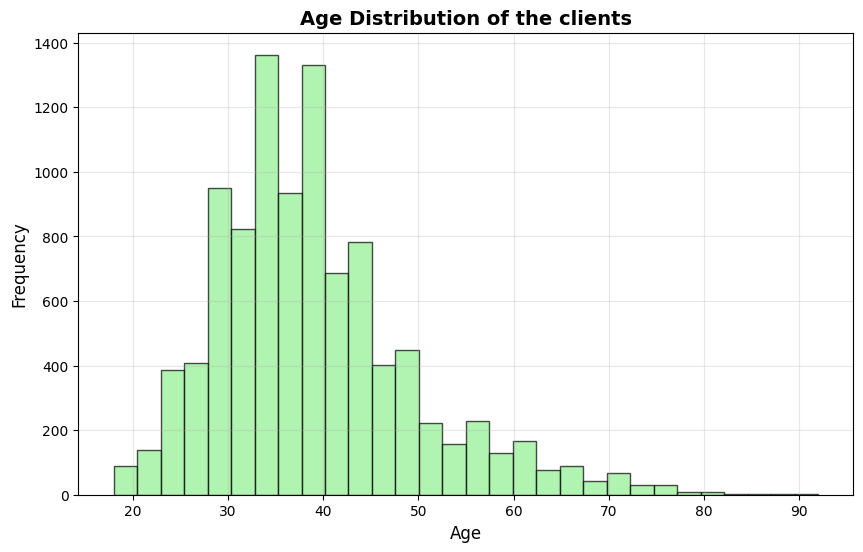

Age statistics:
Min: 18.0, Max: 92.0, Mean: 38.9, Median: 37.0


In [16]:
plt.figure(figsize=(10, 6))
plt.hist(df['Age'], bins=30, color='lightgreen', alpha=0.7, edgecolor='black')
plt.title('Age Distribution of the clients', fontsize=14, fontweight='bold')
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Age statistics:\nMin: {df['Age'].min()}, Max: {df['Age'].max()}, Mean: {df['Age'].mean():.1f}, Median: {df['Age'].median()}")

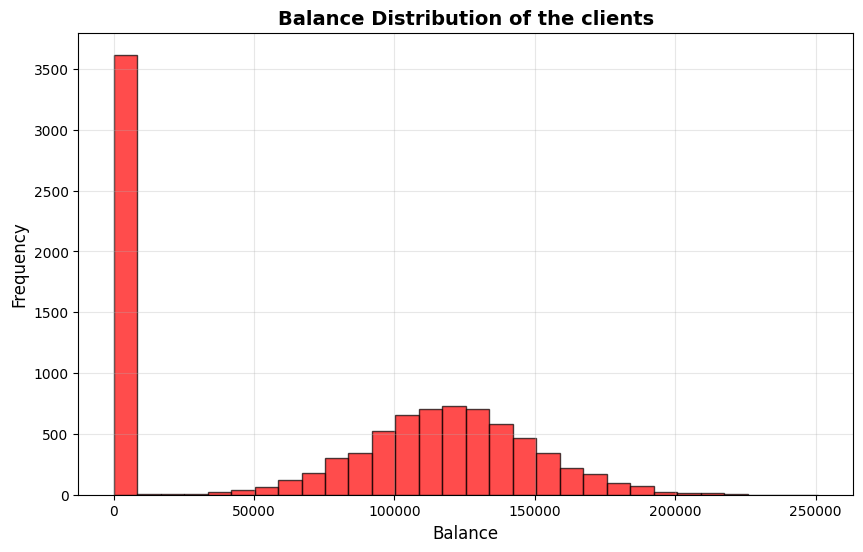

Balance statistics:
Min: 0.0, Max: 250898.09, Mean: 76491.1, Median: 97198.54000000001


In [17]:
plt.figure(figsize=(10, 6))
plt.hist(df['Balance'], bins=30, color='red', alpha=0.7, edgecolor='black')
plt.title('Balance Distribution of the clients', fontsize=14, fontweight='bold')
plt.xlabel('Balance', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Balance statistics:\nMin: {df['Balance'].min()}, Max: {df['Balance'].max()}, Mean: {df['Balance'].mean():.1f}, Median: {df['Balance'].median()}")

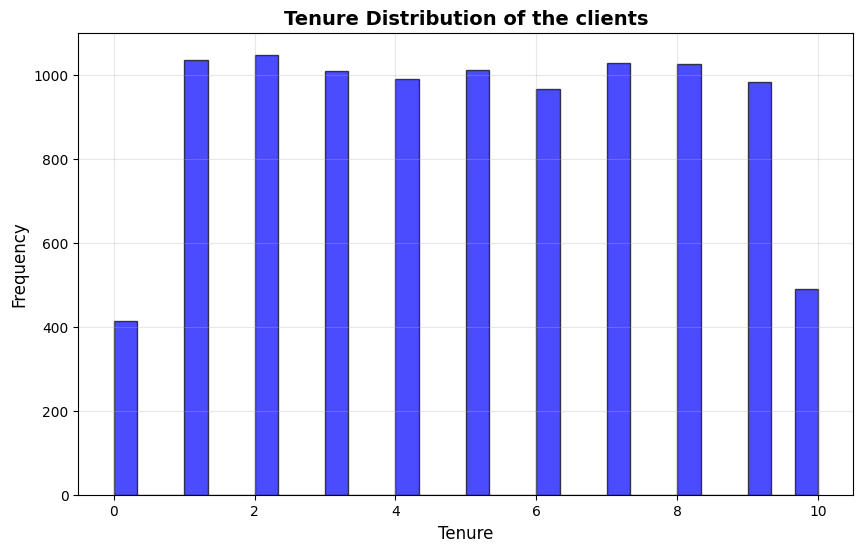

Tenure statistics:
Min: 0, Max: 10, Mean: 5.0, Median: 5.0


In [18]:
plt.figure(figsize=(10, 6))
plt.hist(df['Tenure'], bins=30, color='blue', alpha=0.7, edgecolor='black')
plt.title('Tenure Distribution of the clients', fontsize=14, fontweight='bold')
plt.xlabel('Tenure', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

print(f"Tenure statistics:\nMin: {df['Tenure'].min()}, Max: {df['Tenure'].max()}, Mean: {df['Tenure'].mean():.1f}, Median: {df['Tenure'].median()}")

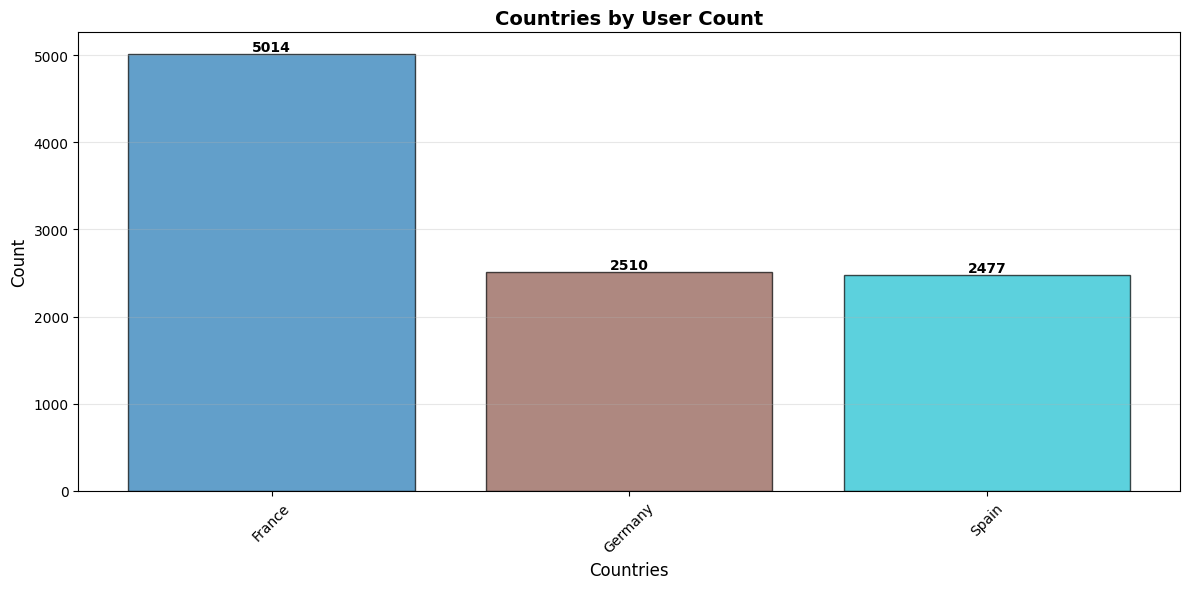

In [19]:
plt.figure(figsize=(12, 6))
country_counts = df['Geography'].value_counts()
colors = plt.cm.tab10(np.linspace(0, 1, len(country_counts)))
plt.bar(country_counts.index, country_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Countries by User Count', fontsize=14, fontweight='bold')
plt.xlabel('Countries', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)
for i, v in enumerate(country_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

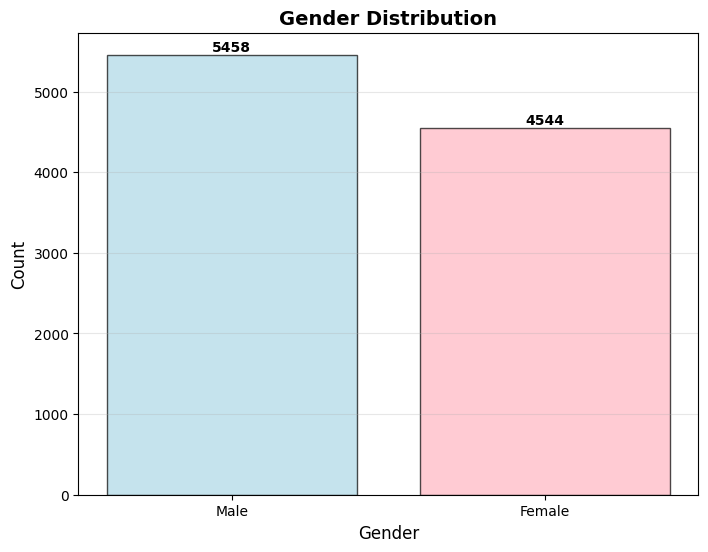

In [20]:
plt.figure(figsize=(8, 6))
gender_counts = df['Gender'].value_counts()
colors = ['lightblue', 'lightpink', 'lightgray']
plt.bar(gender_counts.index, gender_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Gender Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
for i, v in enumerate(gender_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

### ii. exited (Target Variable) distribution by different variables

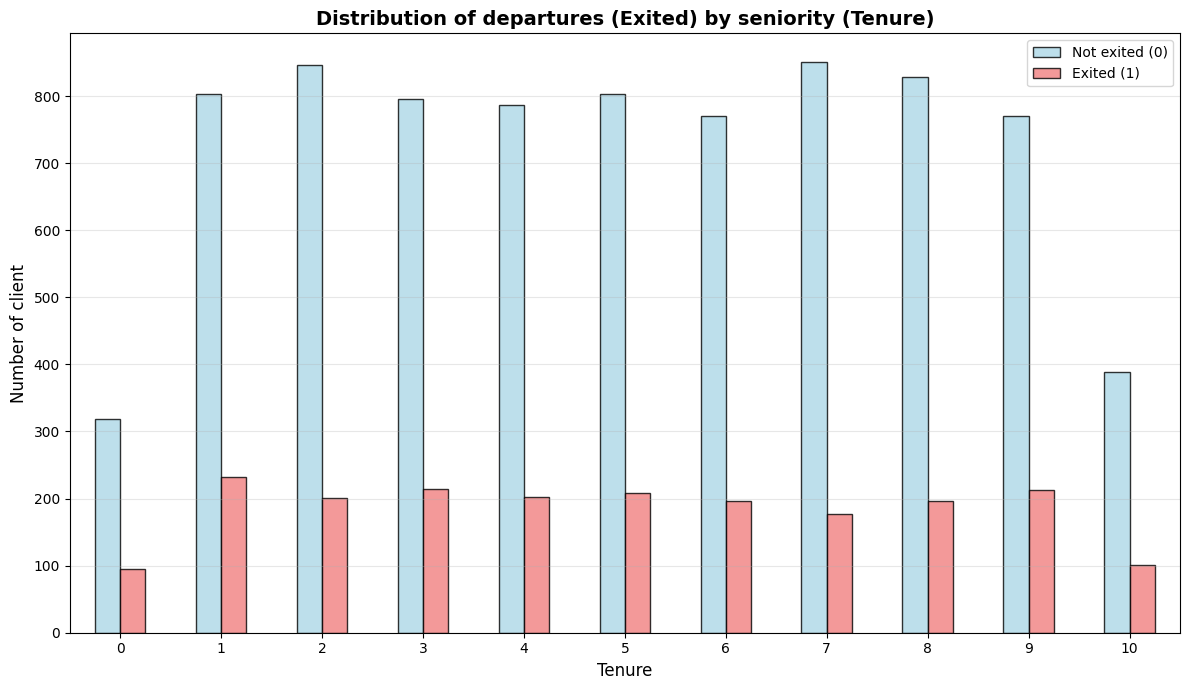

In [21]:
tenure_churn_crosstab = pd.crosstab(df['Tenure'], df['Exited'])

tenure_churn_crosstab.plot(
    kind='bar',
    color=['lightblue', 'lightcoral'],
    alpha=0.8,
    edgecolor='black',
    figsize=(12, 7)
)

plt.title('Distribution of departures (Exited) by seniority (Tenure)', fontsize=14, fontweight='bold')
plt.xlabel('Tenure', fontsize=12)
plt.ylabel('Number of client', fontsize=12)

plt.legend(['Not exited (0)', 'Exited (1)'])
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

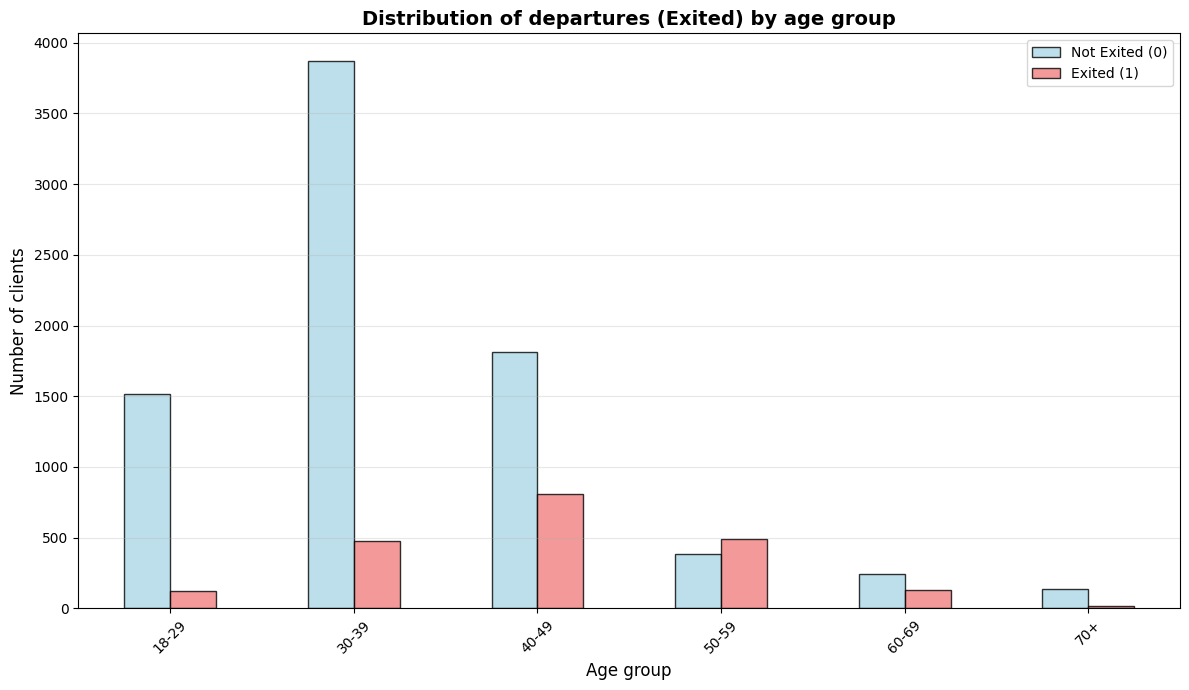

In [22]:
bins = [18, 30, 40, 50, 60, 70, 100]
labels = ['18-29', '30-39', '40-49', '50-59', '60-69', '70+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

age_churn_crosstab = pd.crosstab(df['AgeGroup'], df['Exited'])

age_churn_crosstab.plot(
    kind='bar',
    color=['lightblue', 'lightcoral'],
    alpha=0.8,
    edgecolor='black',
    figsize=(12, 7)
)

plt.title('Distribution of departures (Exited) by age group', fontsize=14, fontweight='bold')
plt.xlabel('Age group', fontsize=12)
plt.ylabel('Number of clients', fontsize=12)
plt.legend(['Not Exited (0)', 'Exited (1)'])
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

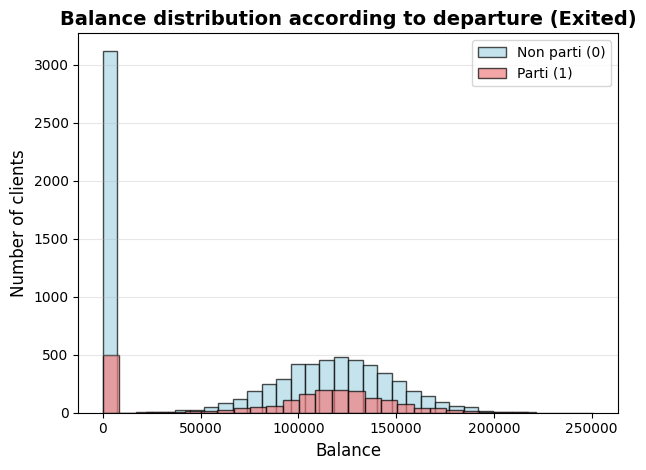

In [23]:
plt.hist(
    df[df['Exited'] == 0]['Balance'],
    bins=30,
    alpha=0.7,
    label='Non parti (0)',
    color='lightblue',
    edgecolor='black'
)

plt.hist(
    df[df['Exited'] == 1]['Balance'],
    bins=30,
    alpha=0.7,
    label='Parti (1)',
    color='lightcoral',
    edgecolor='black'
)

plt.title('Balance distribution according to departure (Exited)', fontsize=14, fontweight='bold')
plt.xlabel('Balance', fontsize=12)
plt.ylabel('Number of clients', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Correlation analysis

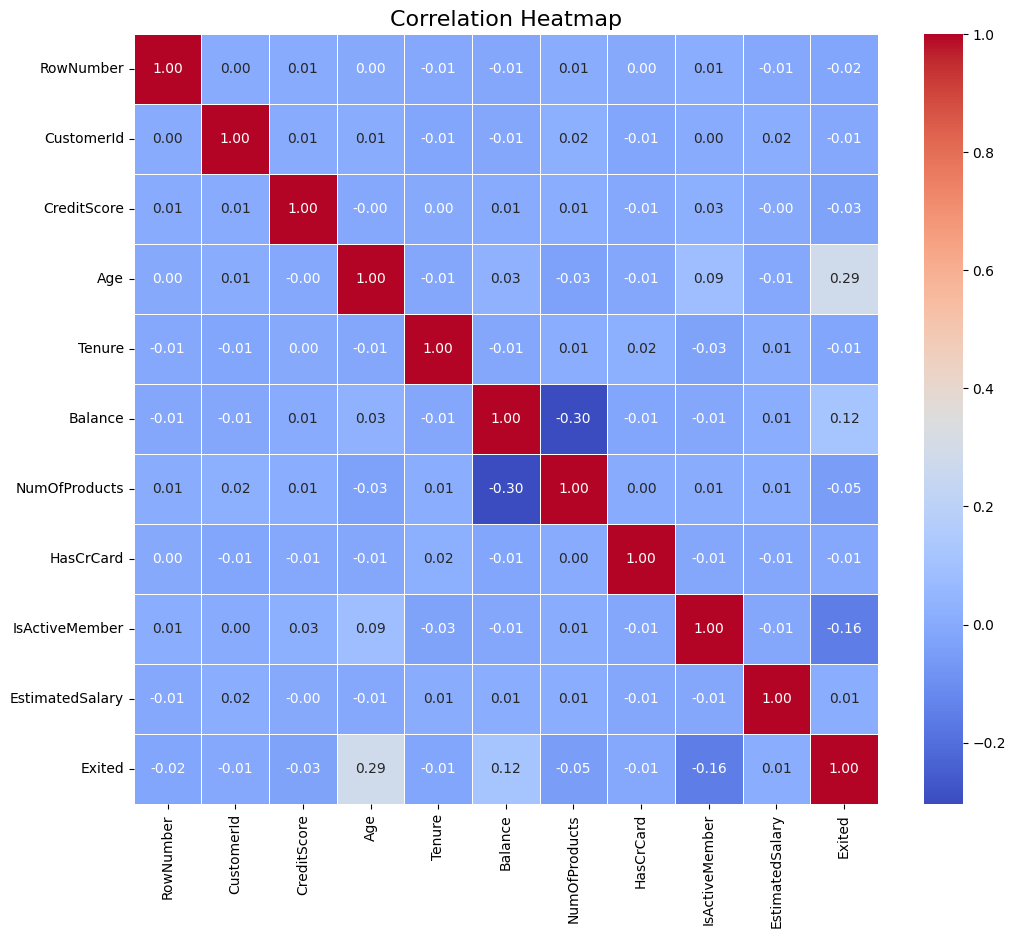

In [24]:
target_col = 'Exited'

numerical_columns = df.select_dtypes(include=['int64', 'float64'])

correlations = numerical_columns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    cbar=True
)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [25]:
numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
print(correlation_matrix['Exited'].abs().sort_values(ascending=False))

Exited             1.000000
Age                0.285318
IsActiveMember     0.156191
Balance            0.118456
NumOfProducts      0.047601
CreditScore        0.026909
RowNumber          0.016308
Tenure             0.014117
EstimatedSalary    0.012123
HasCrCard          0.007009
CustomerId         0.006226
Name: Exited, dtype: float64


## 7. Data balance

In [26]:
class_counts = df['Exited'].value_counts()
print("Class distribution:\n", class_counts)

minority = class_counts.min()
majority = class_counts.max()
ratio = majority / minority
print(f"Imbalance ratio ≈ 1:{ratio:.2f}")

Class distribution:
 Exited
0    7964
1    2038
Name: count, dtype: int64
Imbalance ratio ≈ 1:3.91


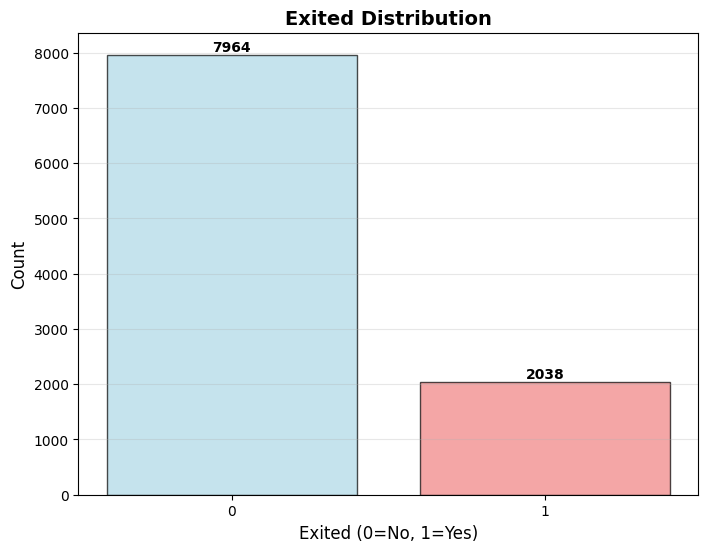

Exited rate: 20.4%


In [27]:
# Target variable distribution
plt.figure(figsize=(8, 6))
inactive_counts = df['Exited'].value_counts()
colors = ['lightblue', 'lightcoral']
plt.bar(inactive_counts.index, inactive_counts.values, color=colors, alpha=0.7, edgecolor='black')
plt.title('Exited Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Exited (0=No, 1=Yes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0, 1])
for i, v in enumerate(inactive_counts.values):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Exited rate: {inactive_counts[1] / len(df) * 100:.1f}%")

This imbalance is not extreme (an extreme imbalance is generally around 1:10, as in fraud detection). However, it is significant enough to require specific attention, because:

- Model Bias: A default model could achieve an Accuracy of 79.5% by simply predicting that no one will inactive. It might completely ignore the minority class, which is unacceptable for a inactive prediction objective.

- Business Objective: The minority class (exited) is the main class of interest (the one the company wants to predict and prevent). Our model must excel at correctly identifying these at-risk users.

**To fix this problem, we are going to use the SMOTE later**

# III. Data pre-processing

## 1. Missing values

In [28]:
missing_values = df.isnull().sum()
print(missing_values)

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          1
Gender             0
Age                1
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          1
IsActiveMember     1
EstimatedSalary    0
Exited             0
AgeGroup           1
dtype: int64


In [29]:
df_clean = df.dropna()

print(f"Original size: {len(df)}")
print(f"Size cleaned: {len(df_clean)}")
print(f"Deleted lines: {len(df) - len(df_clean)}")

Original size: 10002
Size cleaned: 9998
Deleted lines: 4


## 2. Duplicates

In [30]:
if df_clean.duplicated().sum() > 0:
    print(df_clean[df_clean.duplicated(keep=False)])
    print(f"Duplicate rows found: {df.duplicated().sum()}")
else:
    print(" No duplicate rows found")

       RowNumber  CustomerId    Surname  CreditScore Geography  Gender   Age  \
9998        9999    15682355  Sabbatini          772   Germany    Male  42.0   
9999        9999    15682355  Sabbatini          772   Germany    Male  42.0   
10000      10000    15628319     Walker          792    France  Female  28.0   
10001      10000    15628319     Walker          792    France  Female  28.0   

       Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
9998        3   75075.31              2        1.0             0.0   
9999        3   75075.31              2        1.0             0.0   
10000       4  130142.79              1        1.0             0.0   
10001       4  130142.79              1        1.0             0.0   

       EstimatedSalary  Exited AgeGroup  
9998          92888.52       1    40-49  
9999          92888.52       1    40-49  
10000         38190.78       0    18-29  
10001         38190.78       0    18-29  
Duplicate rows found: 2


In [31]:
id_cols = ['RowNumber', 'CustomerId', 'Surname']

feature_cols = [col for col in df_clean.columns if col not in id_cols]

duplicates = df_clean.duplicated(subset=feature_cols).sum()

if duplicates > 0:
    print(f"Duplicate entries found: {duplicates}")

    df_final = df_clean.drop_duplicates(subset=feature_cols, keep='first')

    print(f"Size before deletion: {len(df_clean)}")
    print(f"Size after deletion: {len(df_final)}")

else:
    print("No duplicate entries found.")
    df_final = df_clean.copy()

Duplicate entries found: 2
Size before deletion: 9998
Size after deletion: 9996


In [32]:
df = df_clean

## 3. Inconsistencies

In [33]:
print("Unique values ​​for 'Geography':")
print(df['Geography'].unique())

print("\nUnique values ​​for 'Gender':")
print(df['Gender'].unique())

Unique values ​​for 'Geography':
['France' 'Spain' 'Germany']

Unique values ​​for 'Gender':
['Female' 'Male']


No Inconsistencies here, and we didn't saw any other since the beginning of the work

## 4. Feature Engineering

**Let's create some new interesting features**  
This was not asked in the instructions but it can be really helpful to help our future models to understand better the datas and improve our results.

We clearly saw before that there are a lot of customers with a 0 balance

In [34]:
balance_zero = df[df['Balance'] == 0]
print(f"\nNumber of customers with a balance of 0: {len(balance_zero)}")

if len(balance_zero) > 0:
    churn_rate_without_balance = balance_zero['Exited'].value_counts(normalize=True)
    print("Percentage of 'Exited' customers with a 0 balance:")
    # Access the percentage for 'Exited' (index 1) and format it
    print(f"{churn_rate_without_balance.get(1, 0):.2%}")


Number of customers with a balance of 0: 3616
Percentage of 'Exited' customers with a 0 balance:
13.83%


In [35]:
clients_with_balance = df[df['Balance'] > 0]
churn_rate_with_balance = clients_with_balance['Exited'].mean()

print(f"'Exited' rate for customers with balance > 0: {churn_rate_with_balance:.2%}")

churn_rate_global = df['Exited'].mean()
print(f"Overall 'Exited' Rate: {churn_rate_global:.2%}")

'Exited' rate for customers with balance > 0: 24.10%
Overall 'Exited' Rate: 20.38%


In [36]:
df_model = df.copy()

# Create a 'IsZeroBalance' feature
# 1 if the balance is 0, 0 otherwise
df_model['IsZeroBalance'] = (df_model['Balance'] == 0).astype(int)

print(df_model[['Balance', 'IsZeroBalance']].head(10))

      Balance  IsZeroBalance
0        0.00              1
1    83807.86              0
2   159660.80              0
3        0.00              1
5   113755.78              0
7   115046.74              0
10  102016.72              0
11       0.00              1
12       0.00              1
13       0.00              1


Let's say customer A and B have a tenure equal to 5 years
- Customer A (25 years old) is a very loyal customer. They have been a customer for a significant portion of their adult life.

- Customer B (60 years old) is a very recent customer. They joined you only 5 years ago, perhaps after spending 35 years with a competitor.

These two customers are radically different, but the model, simply seeing Tenure = 5, will struggle to grasp this nuance.

!!! That's what Gemini told me, we will see if this has an impact or not

In [37]:
df_model['TenurePerAge'] = df_model['Tenure'] / (df_model['Age'] + 1) # +1 to avoid division by zero if the age is 0

- For Client A: This €100,000 balance represents two full years of their salary. It's likely their entire savings. They are extremely invested in this bank. Losing this client would be a serious loss.

- For Client B: This €100,000 balance represents only six months of their salary (or 0.5 times). For this high-income client, it might just be a temporary account or spending money. They may be less focused on the service, but also much less loyal because their main assets are elsewhere.

Unfortunately this maybe not working because the feature is an "Estimated Salary"

In [38]:
df_model['BalancePerSalary'] = df_model['Balance'] / (df_model['EstimatedSalary'] + 1e-6) # +1e-6 to avoid division by zero if the salary is 0

In [39]:
bins = [18, 30, 40, 50, 60, 100]
labels = ['18-29', '30-39', '40-49', '50-59', '60+']
df_model['AgeGroup'] = pd.cut(df_model['Age'], bins=bins, labels=labels, right=False)

print("\nChurn Rate by Age Group:")
print(df_model.groupby('AgeGroup')['Exited'].mean())


Churn Rate by Age Group:
AgeGroup
18-29    0.075564
30-39    0.108836
40-49    0.308368
50-59    0.561060
60+      0.279468
Name: Exited, dtype: float64


/tmp/ipython-input-3261978172.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_model.groupby('AgeGroup')['Exited'].mean())


**Let's see if our Feature Engineering worked or not**

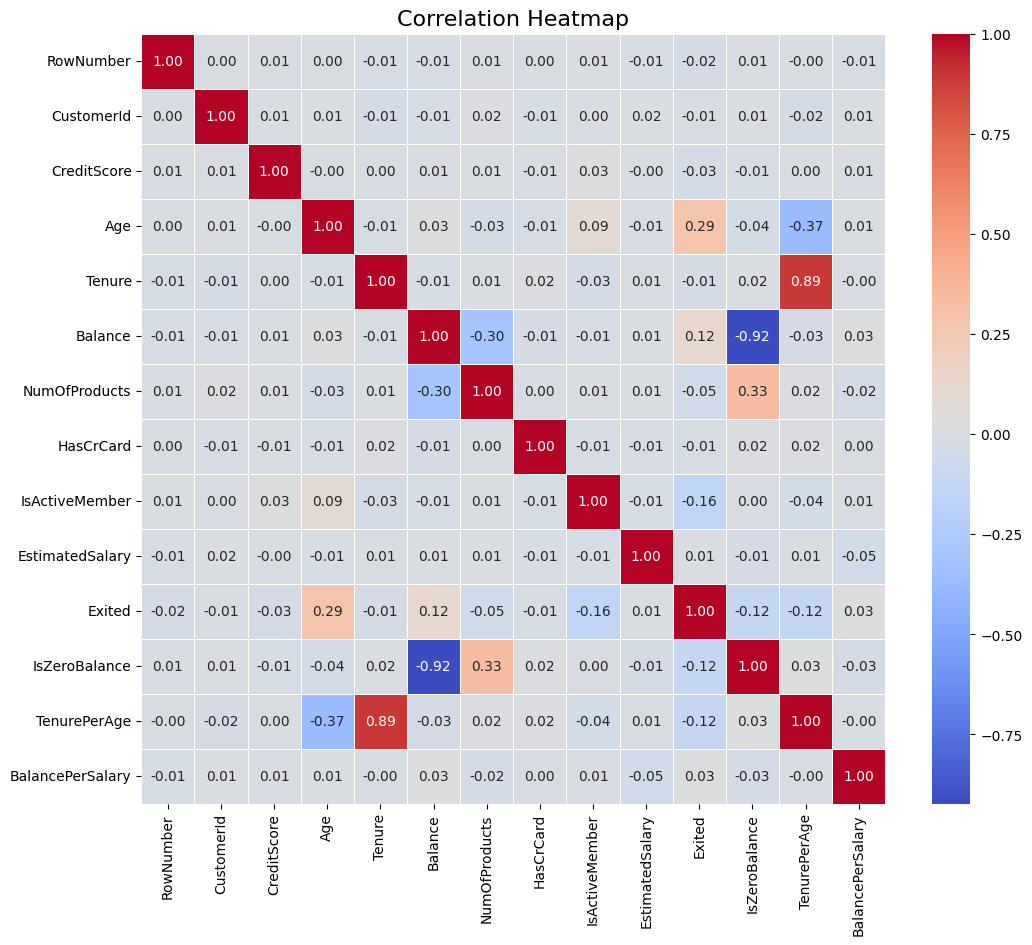

In [40]:
target_col = 'Exited'

numerical_columns = df_model.select_dtypes(include=['int64', 'float64'])

correlations = numerical_columns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    correlations,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,
    cbar=True
)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

In [41]:
numeric_df = df_model.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr()
print(correlation_matrix['Exited'].abs().sort_values(ascending=False))

Exited              1.000000
Age                 0.285448
IsActiveMember      0.156072
IsZeroBalance       0.122510
TenurePerAge        0.119900
Balance             0.118564
NumOfProducts       0.047621
CreditScore         0.026790
BalancePerSalary    0.025544
RowNumber           0.016669
Tenure              0.014208
EstimatedSalary     0.011981
HasCrCard           0.007023
CustomerId          0.006262
Name: Exited, dtype: float64


We can see that some of our new features have a high correlation with our target feature ! Our work should help then !

In [42]:
df = df_model

In [43]:
df.drop(columns=['Age'], inplace=True)

## 5. Outliers

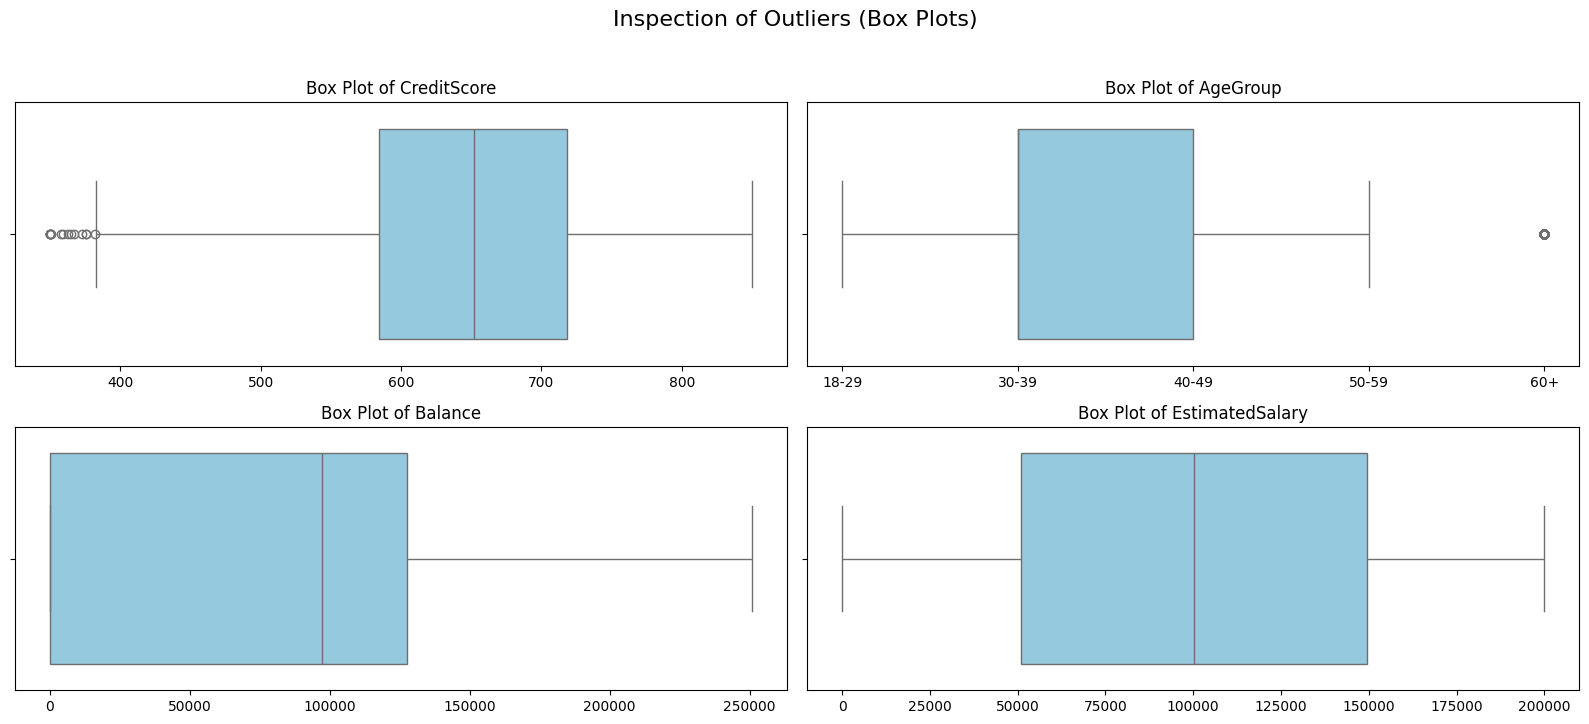

In [44]:
cols_to_check = ['CreditScore', 'AgeGroup', 'Balance', 'EstimatedSalary']

plt.figure(figsize=(16, 10))
plt.suptitle('Inspection of Outliers (Box Plots)', fontsize=16, y=1.02)

for i, col in enumerate(cols_to_check):
    plt.subplot(3, 2, i + 1)
    sns.boxplot(x=df_model[col], color='skyblue')
    plt.title(f'Box Plot of {col}')
    plt.xlabel('')

plt.tight_layout()
plt.show()

We don't think that we need to remove the outliers because in this case the outliers are giving some insights about data.

## 6. Encoding

In [45]:
print(df.groupby('NumOfProducts')['Exited'].mean())

NumOfProducts
1    0.277199
2    0.076051
3    0.827068
4    1.000000
Name: Exited, dtype: float64


/tmp/ipython-input-1371081814.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df['NumOfProducts'], y=df['Exited'], palette='coolwarm')


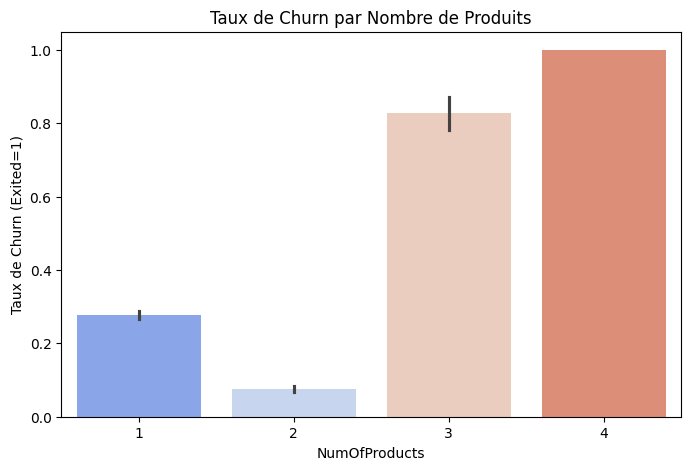

In [46]:
plt.figure(figsize=(8, 5))
sns.barplot(x=df['NumOfProducts'], y=df['Exited'], palette='coolwarm')
plt.title('Taux de Churn par Nombre de Produits')
plt.ylabel('Taux de Churn (Exited=1)')
plt.show()

Here we need to use the One-Hot encoding for this features, but also for those: 'Geography', 'Gender', 'AgeGroup'

In [47]:
df_encoded = pd.get_dummies(
    df,
    columns=['NumOfProducts', 'AgeGroup', 'Geography', 'Gender'],
    drop_first=True
)

## 7. Scaling

In [48]:
numeric_features = ['CreditScore', 'Tenure', 'Balance', 'EstimatedSalary', 'TenurePerAge', 'BalancePerSalary']

In [49]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ],
    remainder='passthrough'
)

## 8. Train-test-split

TODO:
- Séparer en trois:
  - train
  - validation
  - test

In [50]:
y = df_encoded['Exited']
X = df_encoded.drop(columns=['Exited', 'RowNumber', 'CustomerId', 'Surname'])

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% for the final test
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,   # 25% of 80% = 20% of the total
    random_state=42,
    stratify=y_train_val
)

X_train_scaled = preprocessor.fit_transform(X_train)
X_val_scaled = preprocessor.transform(X_val)
X_test_scaled = preprocessor.transform(X_test)

In [51]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("\nDistribution des classes APRES SMOTE (Set d'entraînement) :")
print(pd.Series(y_train_smote).value_counts())


Distribution des classes APRES SMOTE (Set d'entraînement) :
Exited
0    4776
1    4776
Name: count, dtype: int64


# IV. Models

## 1. Fisrt Models

### Logistic Regression

                precision    recall  f1-score   support

Not exited (0)       0.92      0.77      0.84      1592
    Exited (1)       0.45      0.73      0.56       408

      accuracy                           0.76      2000
     macro avg       0.68      0.75      0.70      2000
  weighted avg       0.82      0.76      0.78      2000



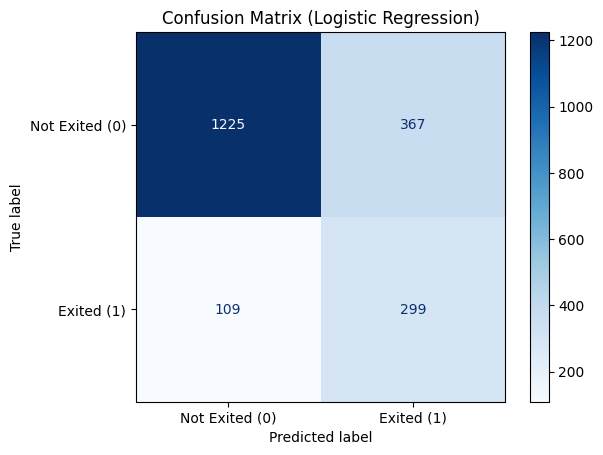

In [52]:
model_lr = LogisticRegression(random_state=42)

model_lr.fit(X_train_smote, y_train_smote)

y_pred = model_lr.predict(X_val_scaled)

print(classification_report(y_val, y_pred, target_names=['Not exited (0)', 'Exited (1)']))
ConfusionMatrixDisplay.from_estimator(
    model_lr,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (Logistic Regression)')
plt.show()

### SVM (Support Vector Machine)

In [53]:
from sklearn.svm import SVC


 Classification Report(SVM)
                precision    recall  f1-score   support

Not Exited (0)       0.91      0.79      0.85      1592
    Exited (1)       0.46      0.69      0.55       408

      accuracy                           0.77      2000
     macro avg       0.68      0.74      0.70      2000
  weighted avg       0.82      0.77      0.79      2000



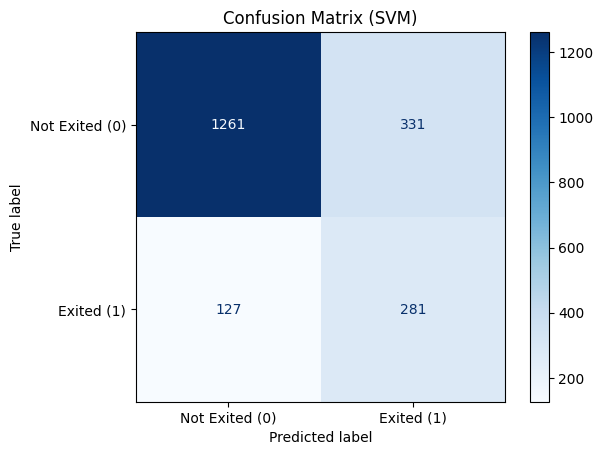

In [54]:
model_svm = SVC(random_state=42)

model_svm.fit(X_train_smote, y_train_smote)

y_pred_svm = model_svm.predict(X_val_scaled)

print("\n Classification Report(SVM)")
print(classification_report(y_val, y_pred_svm, target_names=['Not Exited (0)', 'Exited (1)']))

ConfusionMatrixDisplay.from_estimator(
    model_svm,
    X_val_scaled,
    y_val,
    display_labels=['Not Exited (0)', 'Exited (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix (SVM)')
plt.show()

## 2. Model’s hyperparameter’s tuning

In [55]:
from sklearn.model_selection import GridSearchCV

### Logistic Regression

In [56]:
param_grid_lr = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_lr = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    param_grid_lr,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_lr.fit(X_train_smote, y_train_smote)

print("\nBest parameters for Logistic Regression:")
print(grid_lr.best_params_)

print("\nClassification Report (Tuned LR)")
best_lr = grid_lr.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_val_scaled)
print(classification_report(y_val, y_pred_lr_tuned, target_names=['Not exited (0)', 'Exited (1)']))

Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best parameters for Logistic Regression:
{'C': 0.1}

Classification Report (Tuned LR)
                precision    recall  f1-score   support

Not exited (0)       0.92      0.77      0.84      1592
    Exited (1)       0.45      0.74      0.56       408

      accuracy                           0.76      2000
     macro avg       0.69      0.76      0.70      2000
  weighted avg       0.83      0.76      0.78      2000



In [57]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 1, 0.1]
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_svm.fit(X_train_smote, y_train_smote)

print("\nBest settings for the SVM:")
print(grid_svm.best_params_)

print("\nClassification Report (Tuned SVM)")
best_svm = grid_svm.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_val_scaled)
print(classification_report(y_val, y_pred_svm_tuned, target_names=['Not Exited (0)', 'Exited (1)']))

Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best settings for the SVM:
{'C': 10, 'gamma': 1}

Classification Report (Tuned SVM)
                precision    recall  f1-score   support

Not Exited (0)       0.84      0.92      0.88      1592
    Exited (1)       0.49      0.31      0.38       408

      accuracy                           0.79      2000
     macro avg       0.66      0.61      0.63      2000
  weighted avg       0.77      0.79      0.77      2000



Here we can see that the recall and the f1-score collapsed compared to earlier. This is due to overfitting, so let's move to the next step

# V. Obstacles

## 1. Overfitting

In [58]:
from sklearn.metrics import f1_score

y_pred_lr_train = model_lr.predict(X_train_smote)
y_pred_lr_tuned = best_lr.predict(X_val_scaled)

f1_train = f1_score(y_train_smote, y_pred_lr_train)
f1_val = f1_score(y_val, y_pred_lr_tuned)

print(f"F1-Score (Training LR): {f1_train:.2f}")
print(f"F1-Score (Validation LR): {f1_val:.2f}")

F1-Score (Training LR): 0.78
F1-Score (Validation LR): 0.56


In [59]:
y_pred_svm_train = model_svm.predict(X_train_smote)
y_pred_svm_tuned = model_svm.predict(X_val_scaled)

f1_train = f1_score(y_train_smote, y_pred_svm_train)
f1_val = f1_score(y_val, y_pred_svm_tuned)

print(f"F1-Score (Training SVM): {f1_train:.2f}")
print(f"F1-Score (Validation SVM): {f1_val:.2f}")

F1-Score (Training SVM): 0.84
F1-Score (Validation SVM): 0.55


We understand that both models are overfitting

Let's try if we can correct the overfitting for the SVM model

In [60]:
from imblearn.combine import SMOTETomek

In [61]:
smt = SMOTETomek(random_state=42)
X_train_cleaned, y_train_cleaned = smt.fit_resample(X_train_scaled, y_train)

In [62]:
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 1, 0.1]
}

grid_svm = GridSearchCV(
    SVC(random_state=42),
    param_grid_svm,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_svm.fit(X_train_cleaned, y_train_cleaned)

print("\nBest settings for the SVM:")
print(grid_svm.best_params_)

print("\nClassification Report (Tuned SVM)")
best_svm = grid_svm.best_estimator_
y_pred_svm_tuned = best_svm.predict(X_val_scaled)
print(classification_report(y_val, y_pred_svm_tuned, target_names=['Not Exited (0)', 'Exited (1)']))

Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best settings for the SVM:
{'C': 10, 'gamma': 1}

Classification Report (Tuned SVM)
                precision    recall  f1-score   support

Not Exited (0)       0.84      0.91      0.87      1592
    Exited (1)       0.48      0.31      0.38       408

      accuracy                           0.79      2000
     macro avg       0.66      0.61      0.63      2000
  weighted avg       0.77      0.79      0.77      2000



Didn't worked

It is complicaded to obtain a better model that doesn't overfit. Let's move to the next steps, the more advanced models should probably succeed at avoiding overfitting

## 2. Underfitting

It appears that there is no underfitting

## 3. Data Leakage

During the gridsearch the model has acces to data already transformed by SMOTE and thought he was brilliant, but he was overfitting actually

In [63]:
from imblearn.pipeline import Pipeline

In [64]:
pipe = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42))
])

param_grid_pipe = {
    'svm__C': [0.1, 1, 10],
    'svm__gamma': ['scale', 1, 0.1]
}

grid_pipe = GridSearchCV(
    pipe,                     # We tune the entire pipeline
    param_grid_pipe,
    scoring='f1',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_pipe.fit(X_train, y_train)

print("\nBest settings (via Pipeline):")
print(grid_pipe.best_params_)

print("\nClassification Report (SVM via Pipeline)")
best_model_svm_pipe = grid_pipe.best_estimator_
y_pred_pipe = best_model_svm_pipe.predict(X_val)
print(classification_report(y_val, y_pred_pipe, target_names=['Not exited (0)', 'Exited (1)']))

Fitting 3 folds for each of 9 candidates, totalling 27 fits

Best settings (via Pipeline):
{'svm__C': 0.1, 'svm__gamma': 'scale'}

Classification Report (SVM via Pipeline)
                precision    recall  f1-score   support

Not exited (0)       0.89      0.89      0.89      1592
    Exited (1)       0.58      0.59      0.59       408

      accuracy                           0.83      2000
     macro avg       0.74      0.74      0.74      2000
  weighted avg       0.83      0.83      0.83      2000



With this pipeline we guarantee that the SMOTE is apply *inside* every training loop, which allows to avoid leakage

# VI. Relevant Metrics

TODO: Faudra modifier ça c'est du gemini mais ct bien expliqué

### **Our Strategy for Relevant Metrics**

For our churn prediction project, selecting the correct evaluation metrics is critical due to the **significant class imbalance** in our dataset (approx. 1:3.91, with `Exited = 1` as the minority class).

Our analysis concludes that **Accuracy** is a misleading and irrelevant metric.

Our primary evaluation will be based on a "dashboard" of metrics focused on the minority class (`Exited = 1`):
1.  **F1-Score:** Our **primary optimization metric** (`scoring='f1'`) for balancing the Precision-Recall trade-off.
2.  **Precision vs. Recall:** To be analyzed as a **strategic trade-off** based on business goals (cost of action vs. cost of inaction).
3.  **AUC-ROC:** To be used as a "pure" measure of the model's overall discriminatory power.

---

### **1. The Fallacy of Accuracy**

Due to the 1:3.91 class imbalance, a naive "dummy" model that always predicts `Not Exited` would achieve an Accuracy of approximately 80%. This metric is therefore highly misleading as it does not reflect the model's ability to predict the event we care about (churn). It will not be used for model selection.

### **2. Our Core "Business" Metrics (for `Exited = 1`)**

Our focus is entirely on the model's performance in identifying the minority class.

* **Recall (Sensitivity):**
    * **The Question:** *'Of all the clients who actually churned, what percentage did our model successfully identify?'*
    * **Business Relevance:** This measures the **cost of inaction** (missed opportunities). A high Recall is critical if the primary goal is to "catch" the maximum number of at-risk clients, even if it means generating some false positives.

* **Precision:**
    * **The Question:** *'Of all the clients our model predicted would churn, what percentage actually did?'*
    * **Business Relevance:** This measures the **cost of action**. High Precision is critical if the retention strategy is expensive (e.g., large bonuses, personal calls), as it minimizes resources spent on clients who were not going to leave (false positives).

* **F1-Score:**
    * **The Question:** *'What is the harmonic mean of Precision and Recall?'*
    * **Business Relevance:** This will be our **key optimization metric**. In a context of class imbalance, the F1-Score provides the best single measure of a model's performance by finding a robust balance between the "catch-all" strategy (Recall) and the "no-waste" strategy (Precision).

### **3. The Strategic Trade-off: Using Our Model Results**

Our analysis has already highlighted this critical trade-off. We can present two different models to stakeholders, each suited to a different business strategy:

| Model | Primary Metric | Precision | Recall | F1-Score | Recommended Strategy |
| :--- | :--- | :---: | :---: | :---: | :--- |
| **Logistic Regression (SMOTE)** | **"The Wide Net"** | 0.49 | **0.75** | **0.60** | **Maximize Recall:** Use if retention cost is low (e.g., automated emails). We catch 75% of all churners. |
| **Tuned SVM (Pipeline)** | **"The Sniper"** | **0.60** | 0.56 | 0.58 | **Maximize Precision:** Use if retention cost is high (e.g., advisor calls). 60% of our alerts are correct. |

### **4. Overall Discriminatory Power: AUC-ROC**

Finally, to provide a "pure" statistical measure of a model's ability to distinguish between the two classes (independent of the 50% classification threshold), we will also calculate and compare the **Area Under the ROC Curve (AUC-ROC)**. A score closer to 1.0 indicates a superior model in terms of raw predictive power.

In [65]:
from sklearn.metrics import roc_curve, auc

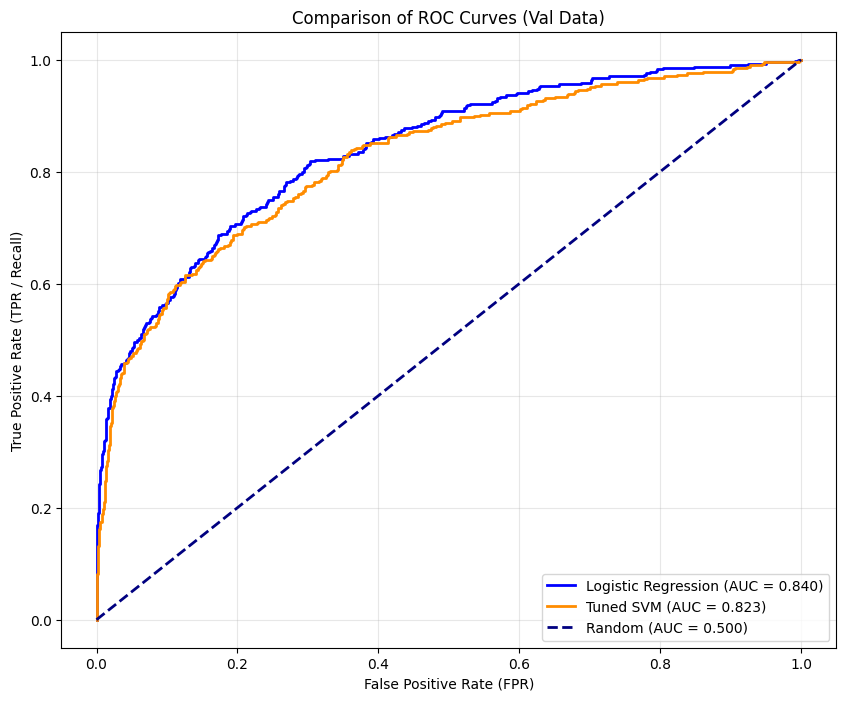

AUC Score (Logistic Regression) : 0.840
AUC Score (Tuned SVM) : 0.823


In [66]:
y_scores_lr = model_lr.predict_proba(X_val_scaled)[:, 1]

y_scores_svm = best_model_svm_pipe.decision_function(X_val)

fpr_lr, tpr_lr, _ = roc_curve(y_val, y_scores_lr)
auc_lr = auc(fpr_lr, tpr_lr)

fpr_svm, tpr_svm, _ = roc_curve(y_val, y_scores_svm)
auc_svm = auc(fpr_svm, tpr_svm)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, color='blue', lw=2,
         label=f'Logistic Regression (AUC = {auc_lr:.3f})')

plt.plot(fpr_svm, tpr_svm, color='darkorange', lw=2,
         label=f'Tuned SVM (AUC = {auc_svm:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random (AUC = 0.500)')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('Comparison of ROC Curves (Val Data)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Score (Logistic Regression) : {auc_lr:.3f}")
print(f"AUC Score (Tuned SVM) : {auc_svm:.3f}")

# VII. Dimension reduction

In [67]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'AgeGroup',
       'IsZeroBalance', 'TenurePerAge', 'BalancePerSalary'],
      dtype='object')

In [68]:
from sklearn.decomposition import PCA

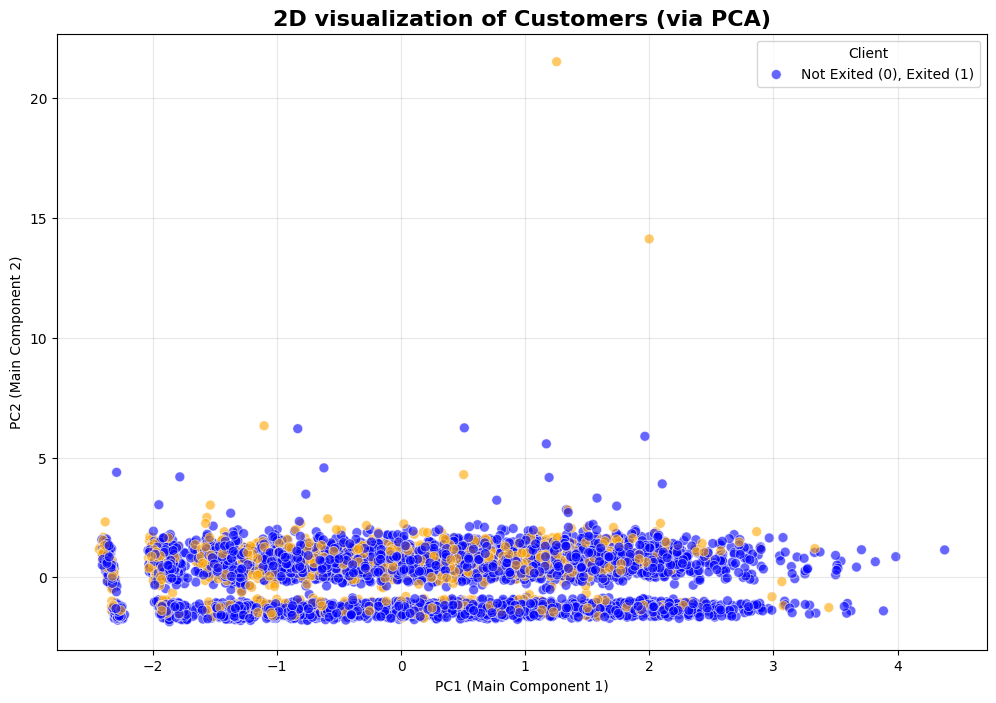

Variance explained by PC1: 23.3%
Variance explained by PC2: 16.3%
Total variance explained by 2 components: 39.6%


In [69]:
pca_2d = PCA(n_components=2)

X_train_pca_2d = pca_2d.fit_transform(X_train_scaled)

df_pca_2d = pd.DataFrame(
    data=X_train_pca_2d,
    columns=['PC1 (Main Component 1)', 'PC2 (Main Component 2)']
)

df_pca_2d['Exited'] = y_train.values

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_pca_2d,
    x='PC1 (Main Component 1)',
    y='PC2 (Main Component 2)',
    hue='Exited',
    palette={0: 'blue', 1: 'orange'},
    alpha=0.6,
    s=50
)

plt.title('2D visualization of Customers (via PCA)', fontsize=16, fontweight='bold')
plt.legend(title='Client', labels=['Not Exited (0), Exited (1)'])
plt.grid(alpha=0.3)
plt.show()

print(f"Variance explained by PC1: {pca_2d.explained_variance_ratio_[0]:.1%}")
print(f"Variance explained by PC2: {pca_2d.explained_variance_ratio_[1]:.1%}")
print(f"Total variance explained by 2 components: {pca_2d.explained_variance_ratio_.sum():.1%}")

Here we have the visual confirmation that our problem is not linear and multi-dimensionnal (because we explane only 39.6% of the variance with a 2D PCA), and this is why our firsts models had trouble being really performant

In [70]:
from imblearn.pipeline import Pipeline as ImblearnPipeline

In [71]:
pipe_pca_model = ImblearnPipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)), # Here we reject 5% of the information
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])

pipe_pca_model.fit(X_train, y_train)

y_pred_pca = pipe_pca_model.predict(X_val)

print("\n--- Classification Report (PCA 95%) ---")
print(classification_report(y_val, y_pred_pca, target_names=['Not Exited (0)', 'Exited (1)']))


--- Classification Report (PCA 95%) ---
                precision    recall  f1-score   support

Not Exited (0)       0.92      0.77      0.84      1592
    Exited (1)       0.45      0.73      0.56       408

      accuracy                           0.76      2000
     macro avg       0.68      0.75      0.70      2000
  weighted avg       0.82      0.76      0.78      2000



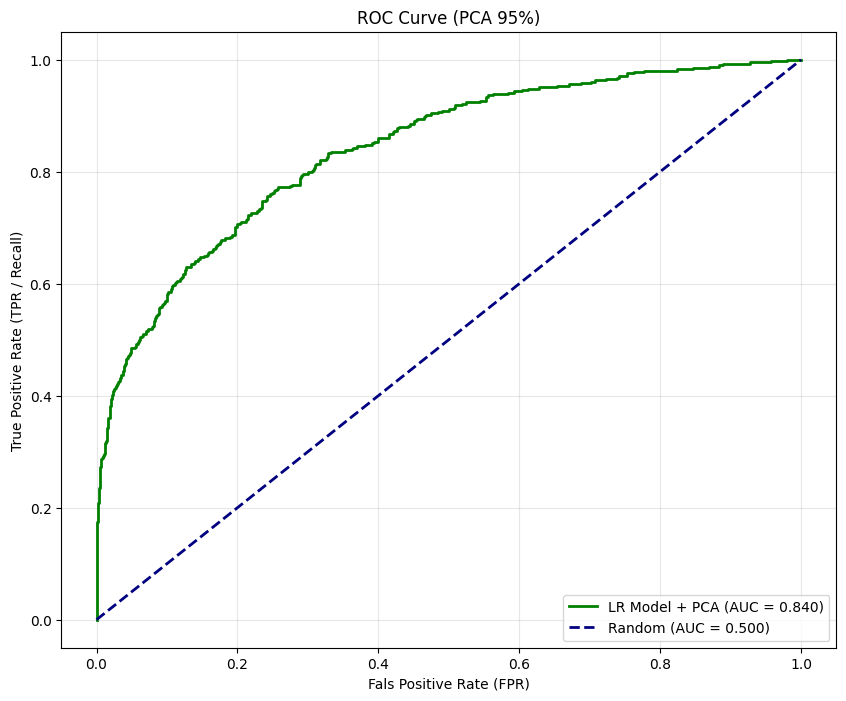

AUC score (LR + PCA) : 0.840


In [72]:
y_scores_pca = pipe_pca_model.predict_proba(X_val)[:, 1]

fpr_pca, tpr_pca, _ = roc_curve(y_val, y_scores_pca)
auc_pca = auc(fpr_pca, tpr_pca)

plt.figure(figsize=(10, 8))
plt.plot(fpr_pca, tpr_pca, color='green', lw=2,
         label=f'LR Model + PCA (AUC = {auc_pca:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--',
         label='Random (AUC = 0.500)')

plt.xlabel('Fals Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR / Recall)')
plt.title('ROC Curve (PCA 95%)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC score (LR + PCA) : {auc_pca:.3f}")

Our f1-score and our ROC-AUC is equal than before. We can conclude that the 5% of the information we rejected was not noise, it was maybe usefull information

# VIII. Advanced Models

## 1. Ensemble models

## 2. Others
TODO: use scientific papers as reference

### The Tree Models

#### Decision Tree

### RandomForestClassifier

### Gradient Boosting Models

#### XGBoost (eXtreme Gradient Boosting)

#### LightGBM (Light Gradient Boosting Machine)

### Neural Networks Models

#### MLP (Multi Layer Perceptron)

# IX. Comparison

# X. Conclusion

## Final Test on the test Data